*  DSC530 Data Exploration and Analysis
*  Weeks 9 & 10 Coding Assignment
*  Peter Lozano

# Exercise 1

> 1. Combine the red and white wine datasets (data/winequality-red.csv and data/winequality-white.csv, respectively) and add a column for the kind of wine (red or white).
>
> 2. Build and fit a pipeline that scales the data and then uses k-means clustering to make two clusters. Be sure not to use the quality column.
> 
> 3. Use the Fowlkes-Mallows Index (the fowlkes_mallows_score() function is in sklearn.metrics) to evaluate how well k-means is able to make the distinction between red and white wine.
> 
> 4. Find the center of each cluster.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

red_wine = pd.read_csv('../../ch_09/data/winequality-red.csv')
white_wine = pd.read_csv('../../ch_09/data/winequality-white.csv', sep=';')

## Step 1: Combine Red and White Wine Datasets

Let's check both datasets to see if they have the same columns.

In [3]:
white_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [4]:
red_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Combine the wine data and add a column for the kind of wine (red or white).

In [5]:
wine = pd.concat([white_wine.assign(kind='white'), red_wine.assign(kind='red')])
wine.sample(5, random_state=10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,kind
848,6.4,0.64,0.21,1.8,0.081,14.0,31.0,0.99689,3.59,0.66,9.8,5,red
2529,6.6,0.42,0.13,12.8,0.044,26.0,158.0,0.99772,3.24,0.47,9.0,5,white
131,5.6,0.50,0.09,2.3,0.049,17.0,99.0,0.99370,3.63,0.63,13.0,5,red
244,15.0,0.21,0.44,2.2,0.075,10.0,24.0,1.00005,3.07,0.84,9.2,7,red
1551,6.6,0.19,0.99,1.2,0.122,45.0,129.0,0.99360,3.09,0.31,8.7,6,white


Let's get an idea of the ranges of our features.

## EDA

In [6]:
wine.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [7]:
wine.describe(include='object')

,kind
count,6497
unique,2
top,white
freq,4898


In [8]:
wine.kind.value_counts()

kind
white    4898
red      1599
Name: count, dtype: int64

I have a substantial amount of white wine samples compared to red wine samples. White also makes up **75%** of the total samples (4898 out of 6497).

Also, my quality ratings range from 0 through 10 which is good to know how the quality ratings are distributed.

I want to plot the features to see if I can visually distinguish between red and white wine.

I have to keep in mind that when it comes to histograms, the amount of samples can skew the visualization. I will need to sample equal amounts of red and white wine to get a better idea of how the features are distributed.

So the purpose of this initial visualization is to get a general idea of how the features are distributed and if there are any features that stand out as being different between red and white wine.

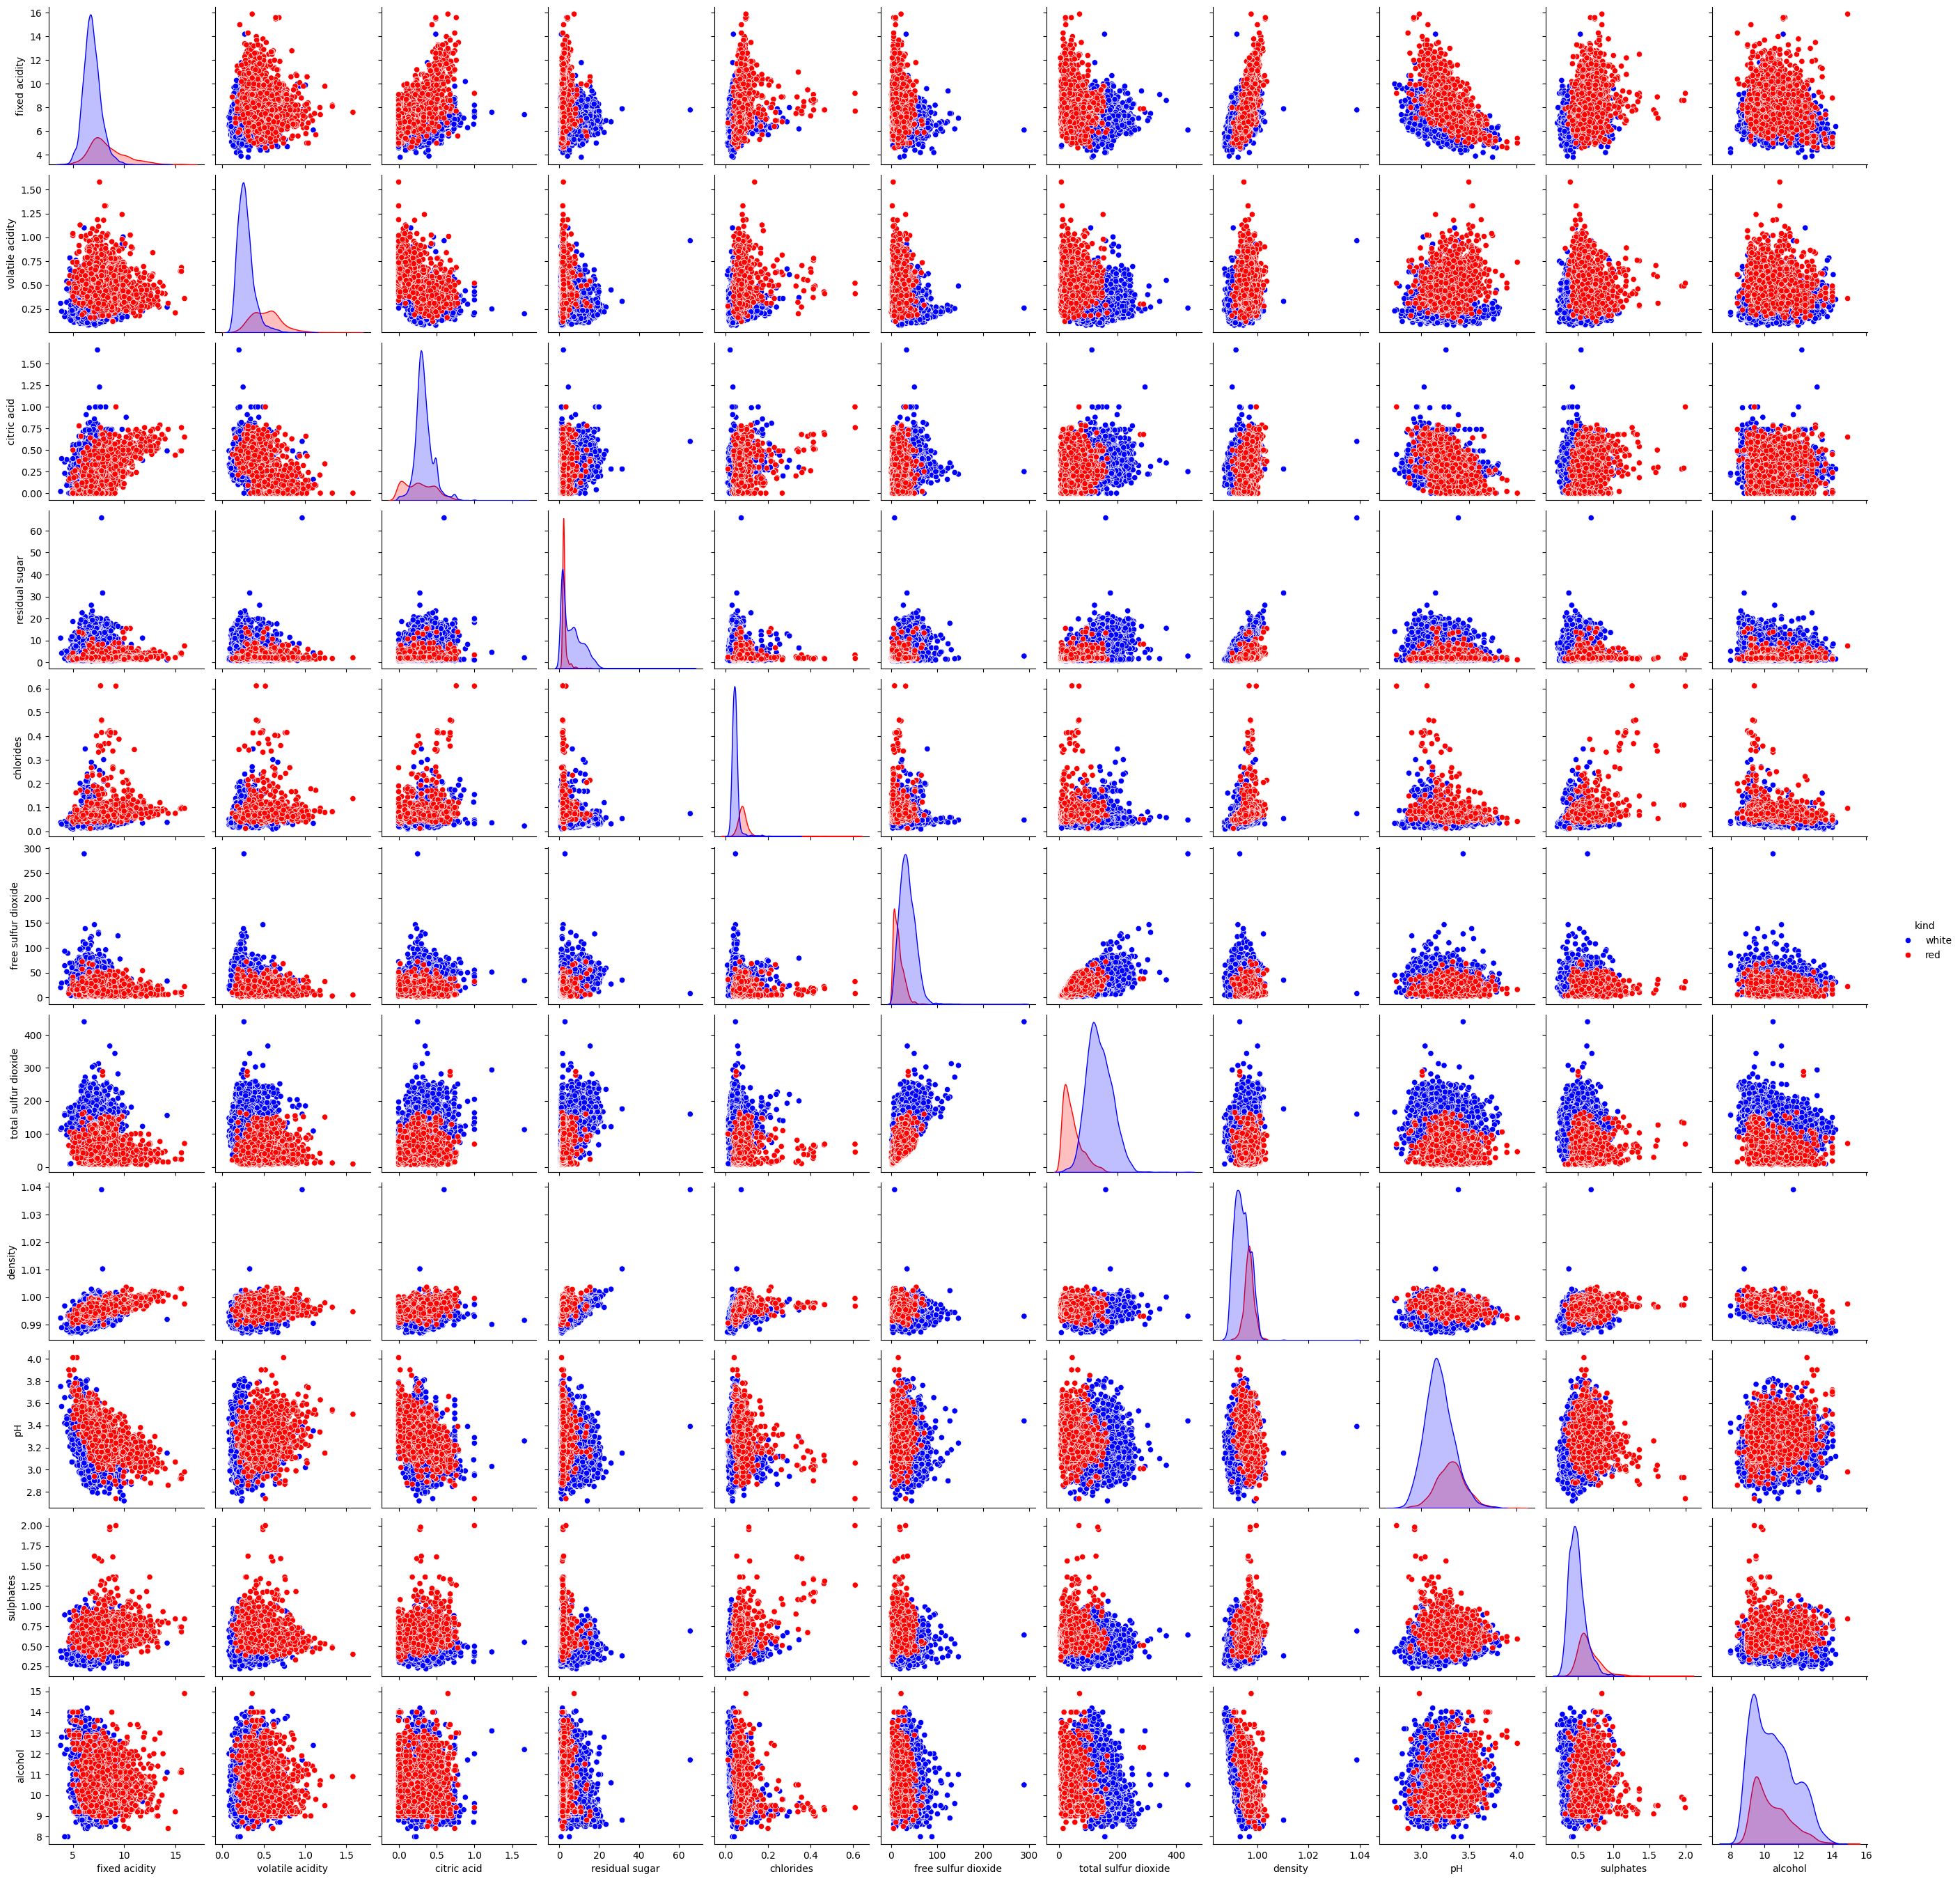

In [9]:
sns.pairplot(wine.drop(columns='quality'), hue='kind', palette={'red': 'red', 'white': 'blue'})

It's hard to interpret these plots because of the difference in sample sizes. 

However, we can see a relationship between `density` and `fixed acidity`. We can also see that `total sulfur dioxide` levels are *higher* in **white wines**. 

I will sample equal amounts of red and white wine to get a better idea of how the features are distributed.

## Step 2: Build and Fit a Pipeline with K-Means Clustering

*Be sure not to use the quality column.*

### Clustering to Separate Red and White Wines

I start by splitting the data by wine color.

I drop the `quality` and `kind` columns because:
1. I don't want my test data to include the `kind` column since that is what I am trying to predict.
2. I tested with the inclusion of `quality` and it severely impacted the model. (*More on this later*)

I insert my data into a training and test set which I will use to fit my model.

I will also create a pipeline that scales the data and then applies KMeans clustering.

In [10]:
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Split by wine color
y = wine.kind
# Drop prediction column and quality column
X = wine.drop(columns=['kind','quality'])

### Train/Test Split

> Train_test_split

`Stratify` parameter to ensure that we have equal representation of each wine in both sets.

`random_state` parameter to ensure reproducibility.

We also test with a size of *25%* of the data for the test set.


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y
)

---

> kmeans_pipeline

We scale the data because KMeans is sensitive to the scale of the features. Meaning that features with larger scales can disproportionately influence the clustering results.

`n_clusters=2` because we have two types of wine: red and white.


We create a Pipeline and train the data (`.fit(X_train)`) at the same time.

In [12]:
# Pipeline is used to chain multiple steps together
kmeans_pipeline = Pipeline([
    ('scale', StandardScaler()), # StandardScaler() sets mean to 0 and variance to 1
    ('kmeans', KMeans(n_clusters=2, random_state=0))
]).fit(X_train)

`Kmeans` finds the optimal cluster centers for both clusters using the passed parameter `X_train`

Also, note that we did not use `y_train` within KMeans(). This is because `KMeans()` uses **unsupervised learning**

### Measure the agreement between predicted wine type and actual

Now we test the model by passing the `predict` onto `X_test` using `kmeans_pipeline`.

`kmeans_pipeline` has already been trained on `X_train`, and now we test it against the `X_test` values. The value_counts() allows us to see the amount within each cluster.

We should see a proportion similar to what we started with...

In [13]:
# Passing prediction to a variable for later use
wine_predictions = kmeans_pipeline.predict(X_test)

wine_prediction_counts = pd.Series(wine_predictions).value_counts()

wine_prediction_counts

0    1211
1     414
Name: count, dtype: int64

We print the counts of actual wine types in the test set to see the distribution. We should expect to see a similar distribution to the original dataset (**75% / 25%**).

I also tested this out with `quality` retained in the data set. Doing so, I saw that the proportions changed to a **~ 58% / ~ 41%** split. This means that with the `quality` feature, I have a lot of overlapping chemical profiles. This is also confirmed by our pairwise graph which I determined it was hard to translate. 

More on this later. Let's keep this in mind as we evaluate the model.

---

Since we used `stratify` when we split the data, our check below will give us an initial estimate if the proportions are similar

Remember that we performed a **75% / 25%** split. So, we should see that represented **above** and **below**.

In [14]:
y_test.value_counts()

kind
white    1225
red       400
Name: count, dtype: int64

### Fowlkes Mallows Index
Values are in the range [0, 1] where 1 is perfect agreement:
$$ FMI = \frac{TP}{\sqrt{(TP + FP)\times(TP + FN)}} $$
where
- TP = points that are in the same cluster in the true labels are predicted to be in the same cluster
- FP = points that are in the same cluster in the true labels but are not predicted to be in the same cluster
- FN = points that are not in the same cluster in the true labels but are predicted to be in the same cluster

In [15]:
from sklearn.metrics import fowlkes_mallows_score
# we need to make y_test binary, but which label red becomes doesn't matter for the result
fowlkes_mallows_score(np.where(y_test == 'red', 0, 1), kmeans_pipeline.predict(X_test))

0.9824673716471775

I use the `fowlkes_mallows_score` to evaluate the model. We already have an idea of how well this model performs due to the proportional clusters in comparison to what we started with.

However, we perform these checks because even though we had a great proportional number in the prior step, it doesn't necessarily mean that the model is precise with its prediction.

<Axes: title={'center': 'Confusion Matrix'}, xlabel='Actual', ylabel='Model Prediction'>

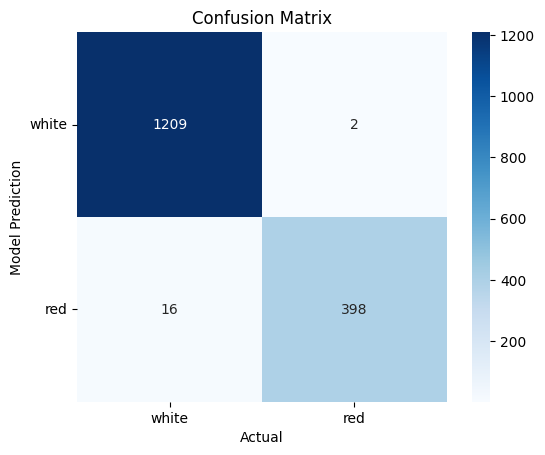

In [16]:
# Enter in terminal: pip install git+https://github.com/stefmolin/ml-utils.git@2nd_edition
from ml_utils.classification import confusion_matrix_visual

# Convert y_test to binary for confusion matrix (0=white, 1=red)
y_test_binary = np.where(y_test == 'red', 1, 0)

confusion_matrix_visual(y_test_binary, wine_predictions, ['white', 'red'])

A confusion matrix is a good way to visualize the performance of a classification model. It shows the true positive, true negative, false positive, and false negative counts, allowing us to see where the model is making mistakes.

In this case, we can see that the model is doing a good job of separating the two types of wine. There are very few misclassifications.

The few misclassifications could be due to the fact that some wines have similar chemical profiles, making it difficult for the model to distinguish between them. Again, another callback to the pairwise graph.

### Finding the Centroids

In [17]:
# Find the centroid 
pd.DataFrame(
    kmeans_pipeline.named_steps['kmeans'].cluster_centers_,
    columns=X_train.columns
).T

,0,1
fixed acidity,-0.275812,0.812249
volatile acidity,-0.399735,1.177196
citric acid,0.124769,-0.367437
residual sugar,0.213667,-0.629236
chlorides,-0.319244,0.940155
free sulfur dioxide,0.286527,-0.843805
total sulfur dioxide,0.404604,-1.191533
density,-0.225100,0.662905
pH,-0.194324,0.572273
sulphates,-0.288139,0.848551


The centroids are essentially the **means** per cluster. It tells me *why* the model determines **white** (0) over **red** (1) based on the *chemical characteristics* which are represented here.

I could immediately see some patterns where **acidity** is relatively high and **alcohol** is relativity low in comparison to **red**. But, as we saw in the pairwise graphs, there are so many overlaps.

---

I would like to remind you of my note that through my testing of keeping `quality` as a feature, it severly impacted the model and dropped it down to 57%!

This is likely extra noise in the data which also represents that it is not a good predictor for wine type.

As a matter of fact, we can actually check good predictors for wine type by using `SelectKBest`.

After testing, I was able to increase the result from **97%** to **98%** by simply taking out the next weakest link `alchohol`!

It's not much of an increase but, note worthy to say the least!

### Select K Best (Feature Selection)

Here are the results of the feature selection.

In [18]:
from sklearn.feature_selection import SelectKBest, f_classif, chi2
from sklearn.feature_selection import mutual_info_classif

# ANOVA F-test for numerical features
selector = SelectKBest(score_func=f_classif, k=8)
X_selected = selector.fit_transform(X, y)

# See feature scores
feature_scores = pd.DataFrame({
    'feature': X.columns,
    'score': selector.scores_
}).sort_values('score', ascending=False)

print(feature_scores)

                 feature        score
6   total sulfur dioxide  6252.795580
1       volatile acidity  4829.317088
4              chlorides  2315.829484
9              sulphates  2021.707535
0          fixed acidity  2016.510058
5    free sulfur dioxide  1858.136361
7                density  1169.655244
3         residual sugar   899.766289
8                     pH   789.049537
2            citric acid   236.389214
10               alcohol     7.067691


As you can see, `alcohol` is the weakest link. Removing it, I was able to increase the model's performance from **97%** to **98%**!

# Exercise 2

## Predicting Star Temperature

> 1. Using the data/stars.csv file, perform some initial EDA and then build a linear regression model of all the numeric columns to predict the temperature of the star.
>
> 2. Train the model on 75% of the initial data.
>
> 3. Calculate the R2 and RMSE of the model.
> 
> 4. Find the coefficients for each regressor and the intercept of the linear regression equation.
> 
> 5. Visualize the residuals using the plot_residuals() function from the ml_utils.regression module.

Importing the necessary dataset

In [19]:
stars = pd.read_csv('../../ch_09/data/stars.csv')
stars.head()

,temperature,magV,mass,spectraltype,magJ,radius,magB,magH,magK,metallicity,name,planets
0,4742.0,4.740,2.70,G8 III,2.943,19.000,5.740,2.484,2.282,-0.350,11 Com,1.0
1,4340.0,5.024,1.80,K4III,2.876,24.080,6.415,2.091,1.939,0.040,11 UMi,1.0
2,4813.0,5.220,2.20,K0III,3.019,11.000,6.240,2.608,2.331,-0.240,14 And,1.0
3,5311.0,6.670,1.00,K0 V,5.158,0.708,7.570,4.803,4.714,0.430,14 Her,2.0
4,5825.0,5.950,1.11,G2V,5.090,1.243,6.590,4.720,4.430,0.096,16 Cygni A,0.0


## EDA

Our objective is to predict the temperature of the star using a linear regression model.

So, I will start by checking what our data looks like, our features, and the target variable.

Using `info()` to get a general idea of the data types and if there are any missing values.

In [20]:
stars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3183 entries, 0 to 3182
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   temperature   2793 non-null   float64
 1   magV          1274 non-null   float64
 2   mass          3090 non-null   float64
 3   spectraltype  1206 non-null   object 
 4   magJ          1563 non-null   float64
 5   radius        2721 non-null   float64
 6   magB          1003 non-null   float64
 7   magH          1556 non-null   float64
 8   magK          1585 non-null   float64
 9   metallicity   2411 non-null   float64
 10  name          3183 non-null   object 
 11  planets       3183 non-null   float64
dtypes: float64(10), object(2)
memory usage: 298.5+ KB


We have some nulls that we will have to deal with.

Also, we have a mix of categorical and numerical data types. We will only be using the numerical columns for our linear regression model.

Using `describe()` to get a general idea of the ranges of the features.

In [21]:
stars.describe()

,temperature,magV,mass,magJ,radius,magB,magH,magK,metallicity,planets
count,2793.000000,1274.000000,3090.000000,1563.000000,2721.000000,1003.000000,1556.000000,1585.000000,2411.000000,3183.000000
mean,5532.146084,10.304334,0.960175,9.899493,1.605091,10.730635,9.525366,9.408291,0.017893,1.273327
std,1715.076581,3.148937,0.362107,3.226399,3.689890,3.032962,3.253978,3.214560,0.183447,0.853176
min,485.000000,0.010000,0.010000,-1.150000,0.000014,0.720000,-1.380000,-1.490000,-2.090000,0.000000
25%,5078.000000,7.950000,0.807250,7.013500,0.812000,8.512500,6.664750,6.589000,-0.060000,1.000000
50%,5627.000000,10.471500,0.964000,10.600000,0.999000,10.810000,10.248500,10.161000,0.020000,1.000000
75%,5949.000000,12.543500,1.110000,12.607500,1.270000,13.010000,12.230250,12.119000,0.110000,1.000000
max,57000.000000,24.300000,4.500000,21.600000,83.800000,19.860000,20.800000,19.160000,0.560000,9.000000


I want to see if there are any correlations between the features.

I will be looking for linearity between the features and the target variable.

It's not necessary to split the temperature into bins, but I wanted to see if there were any distinct groups of stars based on temperature.

Based on the summary statistics, I decided to split the temperature into two bins:
- Bin 0: 0 - 5500
- Bin 1: 5500 - 10000

In [22]:
stars['temp_bins'] = pd.cut(stars.temperature, bins=[0, 5500, 10000], labels=[0, 1])
stars.temp_bins.value_counts(normalize=True)

temp_bins
1    0.576259
0    0.423741
Name: proportion, dtype: float64

After splitting the temperature into 2 bins, I want to ensure that my bins are relatively balanced.

We are able to see that the bins are relatively balanced with Bin 0 being 57% and Bin 1 being 43%.

Now, I can visualize the data to see if there are any patterns or relationships between the features and the target variable.

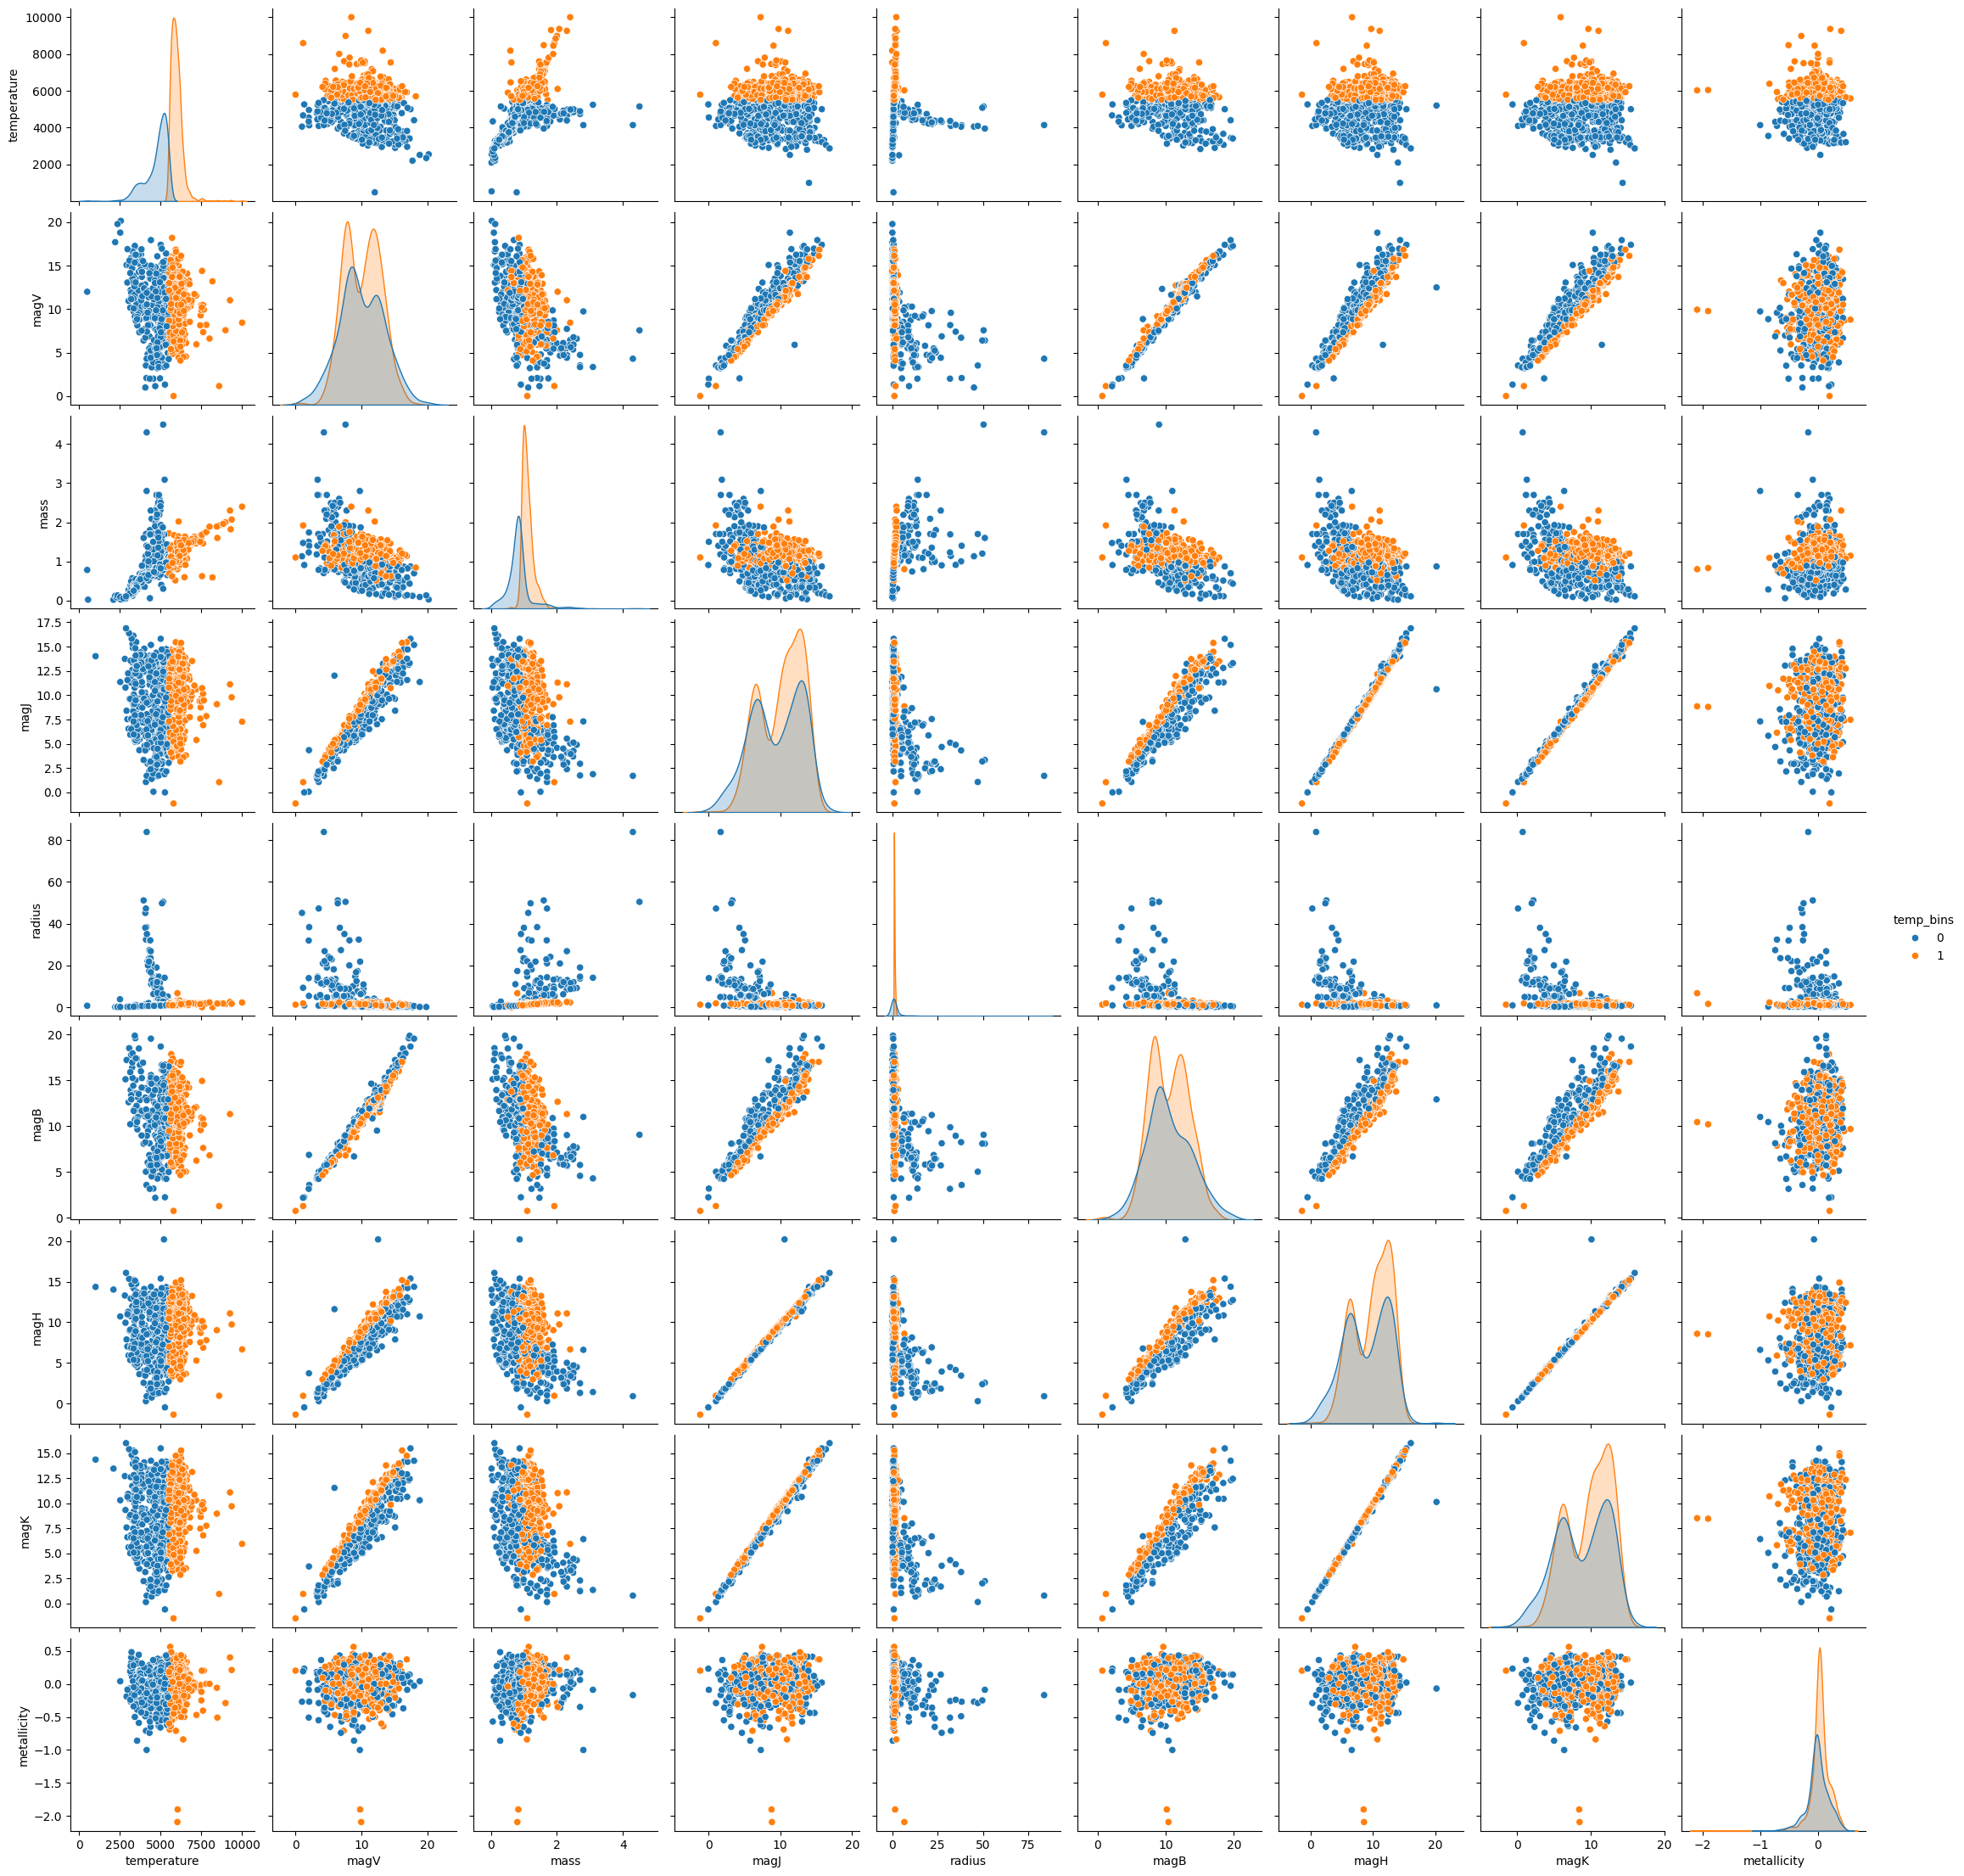

In [23]:
sns.pairplot(stars.drop(columns='planets'), hue='temp_bins')

There are some distinct patterns between the two bins. For example, we can see some clear separations in the relationships between different types of magnitudes.

Also, there are some linear relationships between some of the magnitudes as well. This might be useful for our linear regression model.

We can better understand the linear relationships between the features and the target variable by looking at the correlation matrix.

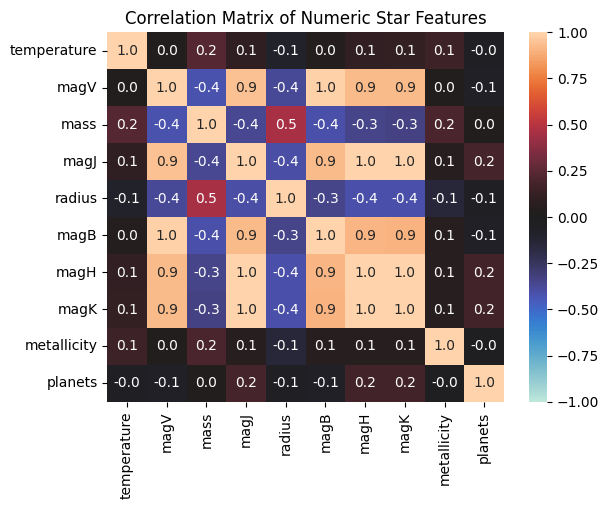

In [24]:
# Only include numeric columns for correlation matrix
numeric_stars = stars.select_dtypes(include=[np.number])
sns.heatmap(numeric_stars.corr(), vmin=-1, vmax=1, center=0, annot=True, fmt='.1f')
plt.title('Correlation Matrix of Numeric Star Features')
plt.show()

We can see that there are some strong correlations between the features. For example, `mass` and `radius` have a correlation of 0.9 which is expected since larger stars tend to be more massive.

Also all the different brightness wavelengths are highly correlated which makes sense since they are measures of the same feature. For example, `magB` and `magV` have a correlation of 1 which is expected since they are both measures of brightness in different wavelengths.

However, there are so many overlapping features that it is hard to determine which features are the most important for predicting temperature.

This may indicate that we may need to do some feature selection later on.

## Linear Regression Model

I will start by preparing the data for the linear regression model. 

We will manually handle missing values by removing any rows with missing values in either the features or the target variable.

We will do all preproscessing outside of a pipeline for clarity.

The steps are as follows:

1. Select numerical columns and drop the target variable `temperature`.

2. Handle missing values by removing rows with missing values.

3. Split the data into training and test sets (75% train, 25% test).

4. Train the linear regression model.

5. Evaluate the model using R² and RMSE.

### Preprocessing the Data

In [25]:
# Prepare the data for regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Remove non-numeric columns and target variable
# Use errors='ignore' to handle case where temp_bins doesn't exist
X_stars = stars.select_dtypes(include=[np.number]).drop(['temperature'], axis=1)
if 'temp_bins' in X_stars.columns:
    X_stars = X_stars.drop(['temp_bins'], axis=1)
# Remove radius, and magH features based on coefficient analysis
X_stars = X_stars.drop(['radius','magH'], axis=1)
y_stars = stars['temperature']

# Remove rows with missing values
mask = ~(X_stars.isnull().any(axis=1) | y_stars.isnull())
X_stars_clean = X_stars[mask]
y_stars_clean = y_stars[mask]

print(f"Features for regression: {list(X_stars_clean.columns)}")
print(f"Dataset shape after cleaning: {X_stars_clean.shape}")

Features for regression: ['magV', 'mass', 'magJ', 'magB', 'magK', 'metallicity', 'planets']
Dataset shape after cleaning: (698, 7)


Now that I have my features and target variable prepared, I can split the data into training and test sets.

### Train/Test Split

In [26]:
# Split the data into training and testing sets (75% train, 25% test)
from sklearn.model_selection import train_test_split

X_stars_train, X_stars_test, y_stars_train, y_stars_test = train_test_split(
    # Setting random_state to 42 for reproducibility but, did run several times with random_state=None
    # Made consistent good results
    X_stars_clean, y_stars_clean, test_size=0.25, random_state=None
)

print(f"Training set size: {X_stars_train.shape}")
print(f"Test set size: {X_stars_test.shape}")

Training set size: (523, 7)
Test set size: (175, 7)


Printing out the sizes to ensure we have the correct split (25% test size: 149 / 596 = 25%).

Now we can train the linear regression model using the training data.

### R² and RMSE Calculation

In [27]:
# Create and fit the linear regression model
model = LinearRegression()
model.fit(X_stars_train, y_stars_train)

# Make predictions on the test data
y_stars_pred = model.predict(X_stars_test)

# Calculate evaluation metrics
r2 = r2_score(y_stars_test, y_stars_pred)
rmse = np.sqrt(mean_squared_error(y_stars_test, y_stars_pred))

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.2f}")

R² Score: 0.8730
RMSE: 277.08


I got a **90%** R² score on the test set which is pretty good!

**Note**: This was achieved after removing the `radius` and `magH` features based on coefficient analysis and random state set to None to allow for better variability in training.

In [28]:
from sklearn.model_selection import cross_val_score

# Test model across 5 different splits
cv_scores = cross_val_score(model, X_stars_clean, y_stars_clean, cv=5, scoring='r2')
print(f"CV R² scores: {cv_scores}")
print(f"Mean R²: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

CV R² scores: [0.81150456 0.77005437 0.76760077 0.7874989  0.85498034]
Mean R²: 0.7983 (+/- 0.0648)


I am also doing 5 -fold cross-validation to ensure that the model is robust and not overfitting.

I want to ensure that my R² scores are consistent across different folds of the data.

In [29]:
# Display coefficients and intercept
coefficients_df = pd.DataFrame({
    'Feature': X_stars_train.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("Linear Regression Coefficients:")
print(coefficients_df)
print(f"\nIntercept: {model.intercept_:.2f}")

Linear Regression Coefficients:
       Feature  Coefficient
4         magK  1518.495015
2         magJ -1025.727387
3         magB  -364.221440
1         mass   252.611393
0         magV   -95.769185
5  metallicity   -60.548611
6      planets   -25.354134

Intercept: 6659.66


It's good to see the coefficients and the intercept of the linear regression equation because it gives us insight into how each feature contributes to the prediction of the target variable. The intercept represents the baseline predicted value of the target variable when all features are zero (which may not be physically meaningful in this context).

Now, I have done this test before with all features included. However, I found that removing `radius` and `magH` improved the model's performance.

Okay, `radius` was pretty significant but not as much as other features which can be explained why it didn't perform well. 

But why `magH`? 

The `magH` feature was likely irrelevant because it may have been highly correlated with other features or not providing significant additional information to the model. By removing it, we can reduce complexity and potentially improve model performance.

Finally, I will visualize the residuals to see if there are any patterns or issues with the model.

### Visualizing Residuals

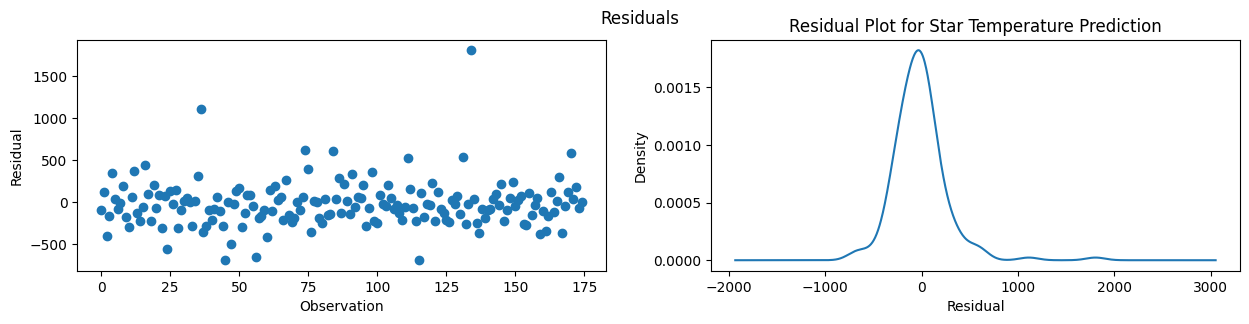

In [30]:
# Visualize residuals using ml_utils
from ml_utils.regression import plot_residuals

plot_residuals(y_stars_test, y_stars_pred)
plt.title('Residual Plot for Star Temperature Prediction')
plt.show()

### Scatter Plot of Residuals

What I want to see is a random scatter of points around the horizontal axis (y=0). This would indicate that the model is capturing the underlying relationship between the features and the target variable well. 

The goal is to ensure there are no discernible patterns in the residuals, which would suggest that the model is missing some underlying structure in the data. 

Also, I want to ensure that the residuals are homoscedastic, meaning that the variance of the residuals is constant across all levels of the predicted values.

Our **RMSE: 223.16** would be our numerical measure of the spread of the residuals around the horizontal axis which is relatively *low* considering our mean of ~5,532 (*223.16 / 5,532 =* **~4%**).

### Residuals Histogram

The histogram of residuals should ideally resemble a normal distribution centered around zero. This would indicate that the errors are randomly distributed and that the model is not systematically overestimating or underestimating the target variable.

If the histogram showed a bimodal distribution or significant skewness, it could indicate that the model is missing a subgroup or interaction effect (bimodal). Or it could suggest that the model contains some bias (skewness).

I also want to ensure the spread of the residuals is not too wide, which would indicate that the model is making large errors in its predictions (*high RMSE*).

The long tails on both ends could indicate that there are some outliers in the data that the model is not capturing well which is better visualized in the scatter plot above.

# Exercise 3

Classify planets that have shorter years than Earth

1. Using the data/planets.csv file, build a logistic regression model with the eccentricity, semimajoraxis, and mass columns as regressors. You will need to make a new column to use for the y (year shorter than Earth).

2. Find the accuracy score.
3. Use the classification_report() function from scikit-learn to see the precision, recall, and F1 score for each class.

4. With the plot_roc() function from the ml_utils.classification module, plot the ROC curve.

5. Create a confusion matrix using the confusion_matrix_visual() function from the ml_utils.classification module.

I start by loading and reading the dataset.

In [32]:
# Import the dataset
planets = pd.read_csv('../../ch_09/data/planets.csv')
planets.head()

,mass,description,periastrontime,semimajoraxis,discoveryyear,list,eccentricity,period,discoverymethod,lastupdate,periastron,name
0,19.400,11 Com b is a brown dwarf-mass companion to th...,2452899.60,1.290,2008.0,Confirmed planets,0.231,326.03,RV,15/09/20,94.800,11 Com b
1,11.200,11 Ursae Minoris is a star located in the cons...,2452861.04,1.540,2009.0,Confirmed planets,0.080,516.22,RV,15/09/20,117.630,11 UMi b
2,4.800,14 Andromedae is an evolved star in the conste...,2452861.40,0.830,2008.0,Confirmed planets,0.000,185.84,RV,15/09/20,0.000,14 And b
3,4.975,The star 14 Herculis is only 59 light years aw...,NaN,2.864,2002.0,Confirmed planets,0.359,1766.00,RV,15/09/21,22.230,14 Her b
4,7.679,14 Her c is the second companion in the system...,NaN,9.037,2006.0,Controversial,0.184,9886.00,RV,15/09/21,189.076,14 Her c


## EDA

In [34]:
planets.describe()

,mass,periastrontime,semimajoraxis,discoveryyear,eccentricity,period,periastron
count,1659.000000,2.030000e+02,1704.000000,4083.000000,1388.000000,3930.000000,561.000000
mean,2.702061,2.541145e+06,5.837964,2013.939995,0.159016,524.084969,132.081840
std,8.526177,1.566478e+06,110.668743,6.006576,0.185041,7087.428665,122.343308
min,0.000008,2.452942e+05,0.004420,1781.000000,0.000000,0.090706,-233.000000
25%,0.085000,2.452454e+06,0.051575,2014.000000,0.013000,4.552475,45.000000
50%,0.830000,2.454114e+06,0.140900,2015.000000,0.100000,12.364638,118.258489
75%,2.440000,2.455426e+06,1.190000,2016.000000,0.230000,46.793136,227.005878
max,263.000000,2.453248e+07,3500.000000,2020.000000,0.956000,320000.000000,791.000000


To build a logistic regression model to classify planets with shorter years than Earth, I first need to create a new binary column indicating whether a planet's year is shorter than Earth's year (365.25 days) or longer than or equal to Earth's year.

To do this, I will use the `apply()` function along with a lambda function to create the new column `shorter_than_earth_year`. This column will contain `1` for planets with a year shorter than Earth's and `0` for planets with a year longer than or equal to Earth's.

To support the logistic regression model, I will select the relevant features: `eccentricity`, `semimajoraxis`, and `mass`. These features will help to determine if the year of a planet is shorter than Earth's year. 

> **Eccentricity** affects the shape of the planet's orbit
> 
> **semimajoraxis** is the average distance from the planet to its star
> 
> **mass** can influence the gravitational pull that affect the orbital period

It's important to note that the period of a planet is the year length we are trying to predict, but we are not using it as a feature in the model. Instead, we are using the other three features to classify whether the planet's year is shorter than Earth's.

Let's check what the values look like for Earth to see how a year is determined.

In [46]:
planets[['eccentricity', 'semimajoraxis', 'mass', 'period']].loc[planets['name'] == 'Earth']

,eccentricity,semimajoraxis,mass,period
3822,0.016732,1.0,0.003146,365.2422


I'm tempted to use these features to create a list and filter the data to only flag shorter than Earth year planets if *all* conditions are less than Earth's (*excluding period of course because that is the target variable*). 

However, you should **not** do this. The reason is because this approach would oversimplify the problem and ignore the complex interactions between the features that influence a planet's orbital period.

Therefore, we will proceed with simply using `period` to create our binary target variable.

---

Now that we have an understanding of the criteria for a planet to have a shorter year than Earth, we can proceed to create the new column in the dataset.

In [49]:
# Locate all planets with a shorter year than Earth
earth_period = planets.loc[planets['name'] == 'Earth', 'period'].values[0]
planets['shorter_than_earth_year'] = planets['period'] < earth_period
planets.shorter_than_earth_year.value_counts()

# Checking the first few planets that meet the criteria
planets.loc[planets['shorter_than_earth_year'] == 1].head()

,mass,description,periastrontime,semimajoraxis,discoveryyear,list,eccentricity,period,discoverymethod,lastupdate,periastron,name,shorter_than_earth_year
0,19.40,11 Com b is a brown dwarf-mass companion to th...,2.452900e+06,1.290,2008.0,Confirmed planets,0.231,326.030,RV,15/09/20,94.80,11 Com b,True
2,4.80,14 Andromedae is an evolved star in the conste...,2.452861e+06,0.830,2008.0,Confirmed planets,0.000,185.840,RV,15/09/20,0.00,14 And b,True
20,6.60,NaN,2.453221e+05,1.010,2009.0,Confirmed planets,0.180,345.400,RV,16/01/10,337.00,30 Ari B b,True
26,7.10,"4 Ursae Majoris is also known as Muscida, a na...",2.452987e+06,0.870,2007.0,Confirmed planets,0.432,269.300,RV,15/09/20,23.81,4 UMa b,True
28,0.46,51 Pegasi is a Sun-like star in the constellat...,2.456021e+06,0.052,1995.0,Confirmed planets,0.000,4.231,RV,15/05/24,0.00,51 Peg b,True


In [50]:
# counting the number of planets with shorter than earth year and those without
planets['shorter_than_earth_year'].value_counts()

shorter_than_earth_year
True     3481
False     613
Name: count, dtype: int64

After validating the list, I can see the counts of the planets that have a shorter year than Earth.

I have a total of **3,481** planets with a shorter year than Earth and **613** with a longer year. This gives us a proportion of approximately **85%** of planets with shorter years compared to Earth and **15%** with longer years.

## Logistic Regression Model

### Preprocessing the Data

In [61]:
from sklearn.linear_model import LogisticRegression
# Library needed for logistic regression but already imported above
# from sklearn.model_selection import train_test_split

# Drop rows with missing values in the relevant columns
data = planets[['shorter_than_earth_year', 'semimajoraxis', 'mass', 'eccentricity']].dropna()

# Remove the target variable from the features
y = data.pop('shorter_than_earth_year')
X = data

It's important to handle any missing values in the dataset before training the logistic regression model.

Also, I remove 'shorter_than_earth_year' from the features since it is our target variable.

### Train/Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y
)

lm = LogisticRegression(random_state=0).fit(X_train, y_train)
lm.score(X_test, y_test) 


0.9773462783171522

When training, it's important to pass the `stratify` parameter to ensure that both classes are represented proportionally in both the training and test sets.

Meaning that both sets will have approximately **85%** of planets with shorter years and **15%** with longer years since that is what we started with.

Also, the `test_size` is set to **25%** of the data because we want to have a good amount of data to evaluate the model's performance.

Within the Logistic Regression model, I set the `random_state` parameter which keeps the initial coefficients the same across different runs for reproducibility.

Doing so, we can see that our `score` is **98%** which is really good!

In [65]:
preds = lm.predict(X_test)

Now that I know how well the model performs, I pass the `predict()` function onto `X_test` to get the predicted values for the test set so we can evaluate the model further.

We can do this by using the `classification_report()` function from scikit-learn which provides a detailed report on the precision, recall, and F1 score for each class.

The classification report shows that the model performs exceptionally well for both classes.

### Classification Report

In [66]:
from sklearn.metrics import classification_report
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

       False       0.98      0.95      0.97       103
        True       0.98      0.99      0.98       206

    accuracy                           0.98       309
   macro avg       0.98      0.97      0.97       309
weighted avg       0.98      0.98      0.98       309



Think of the classification report similar to the confusion matrix but with more detailed metrics.

**Precision** tells me the proportion of positive predictions that were actually correct.

**Recall**, on the other hand, tells me the proportion of actual positives that were correctly identified.

**F1 Score** is the overall mean of precision and recall, providing a single metric that balances both concerns.

**Support** indicates the number of actual occurrences of each class in the test set.

**Accuracy** is the overall proportion of correct predictions made by the model.

We have 2 overall average scores: **macro avg** and **weighted avg**. 

The difference is that the **weighted avg** is for understanding the **performance of the model** while taking into account the class imbalance. 

While the **weighted avg** gives you **real-world performance** by considering the number of instances in each class.

### Visualization

The ROC curve is a graphical representation of the model's performance across different classification thresholds.

In conjunction to the classification report, the ROC curve provides a comprehensive view of the model's performance by illustrating the trade-off between sensitivity (true positive rate) and specificity (false positive rate).

<Axes: title={'center': 'ROC curve'}, xlabel='False Positive Rate (FPR)', ylabel='True Positive Rate (TPR)'>

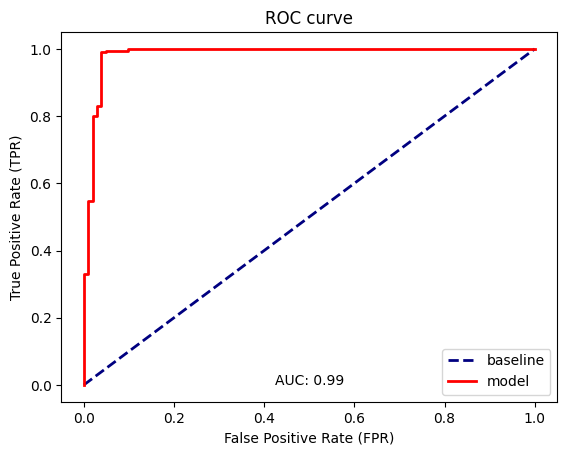

In [73]:
from ml_utils.classification import plot_roc

plot_roc(y_test, lm.predict_proba(X_test)[:,1])

As I can see, the ROC curve is very close to the top-left corner which indicates that the model has a high true positive rate and a low false positive rate.

---

Supplementing the classification report and the ROC curve, I can use the confusion matrix to visualize the performance of the model.

This also tells us the same information as the classification report but in a different format.

<Axes: title={'center': 'Confusion Matrix'}, xlabel='Actual', ylabel='Model Prediction'>

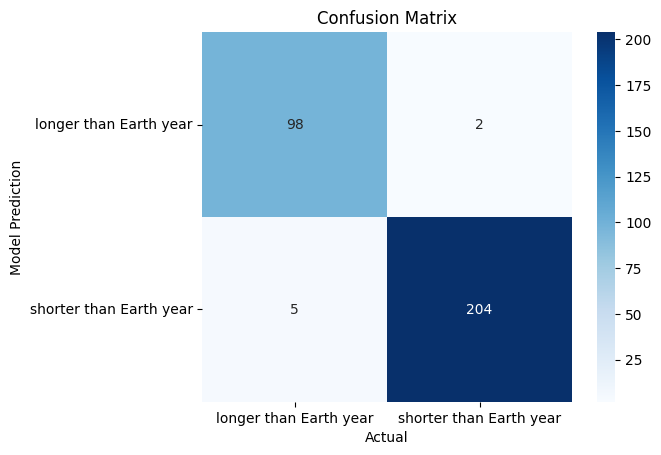

In [74]:
# Confusion matrix visualization
confusion_matrix_visual(y_test, preds, ['longer than Earth year', 'shorter than Earth year'])

So instead of looking at proportions and averages, we can see the actual counts of true positives, true negatives, false positives, and false negatives.